In [1]:
import os
import json
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
from seisLM.model.foundation.pretrained_models import LitMultiDimWav2Vec2

CODE_DIR = "/loggerhead/mikedeffino/Code"

torch version: 2.5.1+cu121
cuda available: True


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
class Config:
    llm_name          = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    seislm_checkpoint = "epoch=39-step=1203000.ckpt"
    sample_rate    = 100
    window_size    = 3000
    input_channels = 3
    embed_dim      = None
    llm_dim        = 2048
    num_prefix_tokens = 2
    projector_hidden  = 512
    cnn_kernel_sizes  = (3, 5, 7)
    projector_dropout = 0.10

    batch_size            = 4      # physical batch (MPS memory limit)
    grad_accum_steps      = 16     # effective batch = 4×16 = 64
    temperature           = 0.07   # keep this
    epochs_stage1         = 20     # was 3 — needs more time



    epochs_stage2  = 20           # can afford more epochs now

    lr_stage1      = 1e-4
    lr_stage2      = 2e-5        # safe with LoRA
    warmup_steps   = 30
    max_grad_norm  = 1.0

    # LoRA hyperparameters
    lora_r         = 8           # rank — higher = more capacity, more VRAM
    lora_alpha     = 16          # scaling = lora_alpha / lora_r = 2.0
    lora_dropout   = 0.05
    lora_targets   = ["q_proj", "v_proj"]   # attention projections only

    hdf5_path    = "chunk2.hdf5"
    jsonl_path   = "waveform_report_m1_d200.jsonl"
    device       = "mps" if torch.backends.mps.is_available() else "cpu"
    dtype        = torch.float32
    max_samples  = 10000
    eval_samples     = 1000    # separate held-out set
    train_split      = 0.9
    max_text_len = 384



cfg = Config()

print(f"--- EQLM with Official Pretrained SeisLM ---")
print(f"--- Device: {cfg.device} ---")


# ==========================================
# 2. DATASET
# ==========================================
class PreFilteredSTEADDataset(Dataset):
    def __init__(self, cfg, tokenizer=None, stage=1, max_text_len=384, split='train'):
        self.cfg          = cfg
        self.tokenizer    = tokenizer
        self.stage        = stage
        self.max_text_len = max_text_len
        self.split        = split

        # ── Load expert reports ───────────────────────────────────────────────
        print(f"📥 Loading reports from {cfg.jsonl_path}...")
        self.reports = {}
        with open(cfg.jsonl_path, 'r') as f:
            for line in f:
                sample   = json.loads(line.strip())
                trace_id = sample.get('id') or sample.get('trace_name')
                if trace_id:
                    self.reports[trace_id] = {
                        'report':   sample.get('report', 'No report available.'),
                        'metadata': sample.get('metadata', {})
                    }
        print(f"  ✓ Loaded {len(self.reports):,} expert reports")

        # ── Open HDF5 ─────────────────────────────────────────────────────────
        print(f"📥 Opening HDF5: {cfg.hdf5_path}")
        self.hdf5_file  = h5py.File(cfg.hdf5_path, 'r')
        self.data_group = self.hdf5_file['data']

        # ── Build aligned trace list ──────────────────────────────────────────
        self.valid_traces = []
        for trace_name in self.reports.keys():
            if trace_name in self.data_group:
                try:
                    wf = np.array(self.data_group[trace_name])
                    if wf.shape == (6000, 3):
                        self.valid_traces.append(trace_name)
                except:
                    continue

        # Cap total before splitting so max_samples is the combined budget
        self.valid_traces = self.valid_traces[:cfg.max_samples]

        # ── Train / eval split ────────────────────────────────────────────────
        n_train = int(len(self.valid_traces) * cfg.train_split)
        if split == 'train':
            self.valid_traces = self.valid_traces[:n_train]
        elif split == 'eval':
            self.valid_traces = self.valid_traces[n_train:]
        else:
            raise ValueError(f"split must be 'train' or 'eval', got '{split}'")

        print(f"  ✓ [{split.upper()}] {len(self):,} waveform-report pairs")

    # ── Length ────────────────────────────────────────────────────────────────
    def __len__(self):
        return len(self.valid_traces)

    # ── Item fetching ─────────────────────────────────────────────────────────
    def __getitem__(self, idx):
        trace_name  = self.valid_traces[idx]
        report_data = self.reports[trace_name]
        expert_report = report_data['report']
        metadata      = report_data.get('metadata', {})

        try:
            dataset = self.data_group.get(trace_name)
            if dataset is None:
                return self._get_synthetic_sample(expert_report, metadata, trace_name)

            waveform = np.array(dataset)
            if waveform.shape == (6000, 3):
                waveform = waveform.T                          # → [3, 6000]

            # Centre-crop to window_size
            if waveform.shape[1] > self.cfg.window_size:
                start    = (waveform.shape[1] - self.cfg.window_size) // 2
                waveform = waveform[:, start:start + self.cfg.window_size]
            elif waveform.shape[1] < self.cfg.window_size:
                pad      = self.cfg.window_size - waveform.shape[1]
                waveform = np.pad(waveform, ((0, 0), (0, pad)), mode='constant')

            # Per-channel z-score normalisation
            for ch in range(3):
                mean = np.mean(waveform[ch])
                std  = np.std(waveform[ch]) + 1e-8
                waveform[ch] = (waveform[ch] - mean) / std

            waveform = torch.tensor(waveform, dtype=torch.float32)

        except Exception:
            return self._get_synthetic_sample(expert_report, metadata, trace_name)

        # ── Stage 2: instruction tuning format ───────────────────────────────
        if self.stage == 2:
           instruction = self._generate_instruction(metadata)
           prompt = f"User: {instruction}\nAssistant:"
           full_text = prompt + " " + expert_report

           if self.tokenizer:
              enc_full = self.tokenizer(
                full_text,
                max_length=self.max_text_len,
                truncation=True,
                padding='max_length',
                return_tensors='pt'
        )
              enc_prompt = self.tokenizer(
                prompt,
                max_length=self.max_text_len,
                truncation=True,
                padding=False,
                return_tensors='pt'
        )

              input_ids = enc_full["input_ids"].squeeze(0)
              attention_mask = enc_full["attention_mask"].squeeze(0)
              labels = input_ids.clone()

              prompt_len = min(enc_prompt["input_ids"].shape[1], labels.shape[0])
              labels[:prompt_len] = -100
              labels[attention_mask == 0] = -100

              return {
                  "waveform": waveform,
                  "input_ids": input_ids,
                  "attention_mask": attention_mask,
                  "labels": labels,
                  "instruction": instruction,
                  "expert_report": expert_report,
                  "trace_name": trace_name,
                  "metadata": json.dumps({k: str(v) for k, v in metadata.items()}) if metadata else "{}"
        }

        # ── Stage 1: contrastive alignment format ─────────────────────────────
        else:
            if self.tokenizer:
                encoding = self.tokenizer(
                    expert_report,
                    max_length=self.max_text_len,
                    truncation=True,
                    padding='max_length',
                    return_tensors='pt'
                )
                return {
                    'waveform':       waveform,
                    'input_ids':      encoding['input_ids'].squeeze(0),
                    'attention_mask': encoding['attention_mask'].squeeze(0),
                    'caption':        expert_report,
                    'trace_name':     trace_name
                }

        return {'waveform': waveform, 'trace_name': trace_name}

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _generate_instruction(self, metadata):
        instructions = [
            "Describe this seismic event in detail.",
            "Generate a preliminary earthquake report.",
            "What can you tell me about this earthquake?",
            "Analyze the seismic waveform and summarize findings.",
            "Provide an emergency response summary for this event."
        ]
        return np.random.choice(instructions)

    def _get_synthetic_sample(self, report, metadata, trace_name):
        waveform = torch.randn(3, self.cfg.window_size, dtype=torch.float32)
        if self.stage == 2:
            metadata_str = json.dumps(
                {k: str(v) for k, v in metadata.items()}
            ) if metadata else "{}"
            return {
                'waveform':      waveform,
                'instruction':   self._generate_instruction(metadata),
                'expert_report': report,
                'trace_name':    trace_name,
                'metadata':      metadata_str
            }
        return {
            'waveform':   waveform,
            'caption':    report,
            'trace_name': trace_name
        }

    # ── Cleanup ───────────────────────────────────────────────────────────────
    def close(self):
        self.hdf5_file.close()

    def __del__(self):
        if hasattr(self, 'hdf5_file'):
            try:
                self.hdf5_file.close()
            except:
                pass


# ==========================================
# 3. MODEL: Fixed SeisLM Output Handling
# ==========================================

class CNNExpert(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, dropout=0.1):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=padding),
            nn.GELU(),
            nn.GroupNorm(1, hidden_dim),
            nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size, padding=padding),
            nn.GELU(),
            nn.GroupNorm(1, hidden_dim)
        )

    def forward(self, x):
        # x: [B, T, D] -> Conv1d expects [B, D, T]
        x = x.transpose(1, 2)
        x = self.net(x)
        return x.mean(dim=-1)   # [B, hidden_dim]


class MultiCNNMoEProjector(nn.Module):
    def __init__(
        self,
        input_dim,
        output_dim,
        num_prefix_tokens=2,
        hidden_dim=512,
        kernel_sizes=(3, 5, 7),
        dropout=0.1
    ):
        super().__init__()
        self.num_prefix_tokens = num_prefix_tokens
        self.hidden_dim = hidden_dim

        self.experts = nn.ModuleList([
            CNNExpert(input_dim, hidden_dim, k, dropout=dropout)
            for k in kernel_sizes
        ])

        self.gate = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, len(kernel_sizes))
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(hidden_dim)
        )

        self.token_queries = nn.Parameter(
            torch.randn(num_prefix_tokens, hidden_dim) * 0.02
        )

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim)
        )

        self.log_temperature = nn.Parameter(torch.tensor([-2.659]))  # log(0.07)

    def forward(self, x):
        """
        x can be:
          [B, T, D]  -> SeisLM sequence features
          [B, D]     -> already pooled features
        returns:
          [B, num_prefix_tokens, output_dim]
        """
        if x.dim() == 2:
            x = x.unsqueeze(1)

        pooled = x.mean(dim=1)                                # [B, D]
        gate_logits = self.gate(pooled)                       # [B, E]
        gate_weights = F.softmax(gate_logits, dim=-1)         # [B, E]

        expert_features = torch.stack(
            [expert(x) for expert in self.experts], dim=1
        )                                                     # [B, E, H]

        fused = (gate_weights.unsqueeze(-1) * expert_features).sum(dim=1)  # [B, H]
        fused = self.fusion(fused)                            # [B, H]

        token_states = fused.unsqueeze(1) + self.token_queries.unsqueeze(0) # [B, N, H]
        prefix_tokens = self.output_proj(token_states)        # [B, N, llm_dim]
        return prefix_tokens

    @property
    def temperature(self):
        return self.log_temperature.exp().clamp(min=0.01, max=0.5)


from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from transformers import AutoModel, AutoTokenizer, AutoModelForCausalLM

class EQLM(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # ── SeisLM (frozen) ──────────────────────────────────────────────────
        print(f"🤖 Loading SeisLM from {cfg.seislm_checkpoint}...")
        lit_model = LitMultiDimWav2Vec2.load_from_checkpoint(
            cfg.seislm_checkpoint,
            map_location='cpu',
            weights_only=False
        )
        self.seislm = lit_model.model.to(cfg.device).eval()
        for p in self.seislm.parameters():
            p.requires_grad = False
        print(f"  ✓ SeisLM loaded: {sum(p.numel() for p in self.seislm.parameters()):,} params")

        # ── Auto-detect SeisLM output dim ────────────────────────────────────
        cfg.embed_dim = self._probe_embed_dim()
        print(f"  ✓ SeisLM output dim: {cfg.embed_dim}")

        # ── Sentence encoder for Stage 1 contrastive alignment (frozen) ──────
        # Produces meaningful 384-dim sentence embeddings — far better than
        # raw LLM input embeddings which are untrained at the sentence level.
        print(f"🤖 Loading sentence encoder...")
        self.text_encoder = AutoModel.from_pretrained(
            "sentence-transformers/all-MiniLM-L6-v2"
        ).to(cfg.device)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        cfg.text_dim = 384   # all-MiniLM-L6-v2 output dim
        print(f"  ✓ Sentence encoder loaded (frozen, dim={cfg.text_dim})")

        # ── Shared alignment dim ─────────────────────────────────────────────
        # Both seismic and text embeddings are projected into this space
        cfg.align_dim = 256

        # Seismic projector: SeisLM dim → align_dim
        # (also used in Stage 2 to project into LLM space via .net)
        self.projector = MultiCNNMoEProjector(
            cfg.embed_dim,
            cfg.llm_dim,
            num_prefix_tokens=cfg.num_prefix_tokens,
            hidden_dim=cfg.projector_hidden,
            kernel_sizes=cfg.cnn_kernel_sizes,
            dropout=cfg.projector_dropout
        ).to(cfg.device)
        print(f"  ✓ Projector: Multi-CNN + MoE ({len(cfg.cnn_kernel_sizes)} experts, {cfg.num_prefix_tokens} prefix tokens)")

        # Separate lightweight head for contrastive alignment only
        # Projects seismic features → shared 256-dim space
        self.seismic_align_head = nn.Sequential(
            nn.Linear(cfg.embed_dim, cfg.align_dim),
            nn.GELU(),
            nn.LayerNorm(cfg.align_dim)
        ).to(cfg.device)

        # Projects sentence embeddings → shared 256-dim space
        self.text_align_head = nn.Sequential(
            nn.Linear(cfg.text_dim, cfg.align_dim),
            nn.GELU(),
            nn.LayerNorm(cfg.align_dim)
        ).to(cfg.device)

        # ── LLM base ─────────────────────────────────────────────────────────
        print(f"🤖 Loading LLM: {cfg.llm_name}...")
        base_llm = AutoModelForCausalLM.from_pretrained(
            cfg.llm_name,
            torch_dtype=cfg.dtype
        )
        base_llm.config.pad_token_id = base_llm.config.eos_token_id

        # ── Wrap LLM with LoRA ───────────────────────────────────────────────
        lora_config = LoraConfig(
            task_type=TaskType.CAUSAL_LM,
            r=cfg.lora_r,
            lora_alpha=cfg.lora_alpha,
            lora_dropout=cfg.lora_dropout,
            target_modules=cfg.lora_targets,
            bias="none",
            inference_mode=False
        )
        self.llm = get_peft_model(base_llm, lora_config)
        self.llm.to(cfg.device)

        trainable, total = self._count_params(self.llm)
        print(f"  ✓ LLM with LoRA — trainable: {trainable:,} / {total:,} "
              f"({100*trainable/total:.2f}%)")

    # ── Helpers ──────────────────────────────────────────────────────────────
    @staticmethod
    def _count_params(model):
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in model.parameters())
        return trainable, total

    @torch.no_grad()
    def _probe_embed_dim(self):
        dummy = torch.zeros(1, self.cfg.input_channels, self.cfg.window_size,
                            device=self.cfg.device)
        out = self.seislm(dummy)
        return self._extract_features(out).shape[-1]

    @staticmethod
    def _extract_features(seislm_output):
        if hasattr(seislm_output, 'last_hidden_state') \
                and seislm_output.last_hidden_state is not None:
            return seislm_output.last_hidden_state
        if hasattr(seislm_output, 'projected_states') \
                and seislm_output.projected_states is not None:
            return seislm_output.projected_states
        if hasattr(seislm_output, 'hidden_states') \
                and seislm_output.hidden_states is not None:
            return seislm_output.hidden_states[-1]
        if isinstance(seislm_output, (tuple, list)) and seislm_output[0] is not None:
            return seislm_output[0]
        raise RuntimeError(f"Cannot extract features from: {type(seislm_output)}")

    def encode_text(self, input_ids, attention_mask):
        """
        Mean-pooled sentence embedding from the frozen sentence encoder.
        Returns [B, 384].
        """
        with torch.no_grad():
            out       = self.text_encoder(input_ids=input_ids,
                                          attention_mask=attention_mask)
            token_emb = out.last_hidden_state                       # [B, L, 384]
            mask      = attention_mask.unsqueeze(-1).float()
            # Masked mean pooling
            sentence_emb = (token_emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return sentence_emb                                          # [B, 384]

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, waveforms, input_ids=None, attention_mask=None,
                labels=None, stage=1):

        # Seismic encoding (always frozen)
        with torch.no_grad():
            seismic_features = self._extract_features(self.seislm(waveforms))
        seismic_emb = seismic_features.mean(dim=1)                  # [B, embed_dim]

        # ── Stage 1: contrastive alignment ───────────────────────────────────
        if stage == 1:
            # Project seismic → shared alignment space
            wav_aligned = self.seismic_align_head(seismic_emb)      # [B, 256]

            # Encode text with sentence encoder → shared alignment space
            txt_emb     = self.encode_text(input_ids, attention_mask)  # [B, 384]
            txt_aligned = self.text_align_head(txt_emb)             # [B, 256]

            return wav_aligned, txt_aligned

        # ── Stage 2: instruction tuning ───────────────────────────────────────
        # Project the full SeisLM sequence with Multi-CNN + MoE
        projected_emb = self.projector(seismic_features)              # [B, N, llm_dim]

        batch_size    = waveforms.shape[0]
        prefix_length = projected_emb.shape[1]

        text_emb      = self.llm.get_input_embeddings()(input_ids)    # [B, L, llm_dim]
        combined_emb  = torch.cat([projected_emb, text_emb], dim=1)   # [B, N+L, llm_dim]

        prefix_mask      = torch.ones(batch_size, prefix_length,
                                      device=attention_mask.device)
        combined_mask    = torch.cat([prefix_mask, attention_mask], dim=1)

        if labels is not None:
            prefix_labels   = torch.full((batch_size, prefix_length), -100,
                                         dtype=labels.dtype, device=labels.device)
            combined_labels = torch.cat([prefix_labels, labels], dim=1)
        else:
            combined_labels = None

        return self.llm(
            inputs_embeds=combined_emb,
            attention_mask=combined_mask,
            labels=combined_labels
        )



# ==========================================
# 4. TRAINING FUNCTIONS
# ==========================================
'''
def contrastive_loss(sim_matrix, temperature=0.07):
    batch_size = sim_matrix.shape[0]
    labels = torch.arange(batch_size).to(sim_matrix.device)
    loss_i = F.cross_entropy(sim_matrix / temperature, labels)
    loss_j = F.cross_entropy(sim_matrix.T / temperature, labels)
    return (loss_i + loss_j) / 2

'''

def contrastive_loss(wav_emb, txt_emb, temperature=0.07, hard_neg_weight=0.5):
    """
    Mix standard in-batch negatives with hard negatives (closest wrong pairs).
    """
    batch_size = wav_emb.shape[0]
    labels     = torch.arange(batch_size, device=wav_emb.device)

    sim = torch.matmul(wav_emb, txt_emb.T)  # [B, B]

    # Standard contrastive loss
    loss_standard = (F.cross_entropy(sim / temperature, labels) +
                     F.cross_entropy(sim.T / temperature, labels)) / 2

    # Hard negative: for each anchor, find the hardest wrong negative
    with torch.no_grad():
        # Mask out the diagonal (correct pairs)
        sim_masked = sim.clone()
        sim_masked.fill_diagonal_(-1e9)
        hard_neg_idx = sim_masked.argmax(dim=1)  # closest wrong text for each wav

    hard_neg_txt   = txt_emb[hard_neg_idx]       # [B, D]
    pos_sim        = (wav_emb * txt_emb).sum(dim=1, keepdim=True)   # [B, 1]
    neg_sim        = (wav_emb * hard_neg_txt).sum(dim=1, keepdim=True)  # [B, 1]
    hard_logits    = torch.cat([pos_sim, neg_sim], dim=1) / temperature
    hard_labels    = torch.zeros(batch_size, dtype=torch.long, device=wav_emb.device)
    loss_hard      = F.cross_entropy(hard_logits, hard_labels)

    return loss_standard + hard_neg_weight * loss_hard


def train_stage1(model, cfg, tokenizer):
    print(f"\n{'='*70}")
    print("STAGE 1: CONTRASTIVE ALIGNMENT")
    print(f"{'='*70}")

    # Freeze everything except the two alignment heads
    for p in model.seislm.parameters():
        p.requires_grad = False
    for p in model.llm.parameters():
        p.requires_grad = False
    for p in model.projector.parameters():
        p.requires_grad = False

    trainable_params = (
        list(model.seismic_align_head.parameters()) +
        list(model.text_align_head.parameters()) +
        [model.projector.log_temperature]
    )

    optimizer = torch.optim.AdamW(
        trainable_params,
        lr=cfg.lr_stage1,
        weight_decay=0.01
    )

    train_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='train'
    )
    val_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='eval'
    )

    train_loader = DataLoader(
        train_dataset, batch_size=cfg.batch_size,
        shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.batch_size,
        shuffle=False, num_workers=0
    )

    train_loss_history = []
    val_loss_history = []

    for epoch in range(cfg.epochs_stage1):
        # ======================
        # Train
        # ======================
        model.train()
        epoch_loss = 0.0
        valid_updates = 0

        optimizer.zero_grad()
        accumulated_wav, accumulated_txt = [], []

        for batch_idx, batch in enumerate(train_loader):
            waveforms = batch["waveform"].to(cfg.device)
            input_ids = batch["input_ids"].to(cfg.device)
            attention_mask = batch["attention_mask"].to(cfg.device)

            wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)
            accumulated_wav.append(F.normalize(wav_emb, p=2, dim=1))
            accumulated_txt.append(F.normalize(txt_emb, p=2, dim=1))

            if ((batch_idx + 1) % cfg.grad_accum_steps == 0) or ((batch_idx + 1) == len(train_loader)):
                wav_big = torch.cat(accumulated_wav, dim=0)
                txt_big = torch.cat(accumulated_txt, dim=0)

                loss = contrastive_loss(
                    wav_big,
                    txt_big,
                    temperature=model.projector.temperature
                )

                if torch.isfinite(loss):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(trainable_params, cfg.max_grad_norm)
                    optimizer.step()
                    epoch_loss += loss.item()
                    valid_updates += 1
                else:
                    print(f"  ⚠ Non-finite loss at batch {batch_idx} — skipping")

                optimizer.zero_grad()
                accumulated_wav, accumulated_txt = [], []

                if batch_idx % 20 == 0:
                    print(
                        f"  Epoch {epoch+1} Batch {batch_idx}/{len(train_loader)} "
                        f"Loss: {loss.item():.4f} "
                        f"Temp: {model.projector.temperature.item():.4f}"
                    )

        avg_train = epoch_loss / max(1, valid_updates)

        # ======================
        # Validation
        # ======================
        model.eval()
        val_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                waveforms = batch["waveform"].to(cfg.device)
                input_ids = batch["input_ids"].to(cfg.device)
                attention_mask = batch["attention_mask"].to(cfg.device)

                wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)
                wav_emb = F.normalize(wav_emb, p=2, dim=1)
                txt_emb = F.normalize(txt_emb, p=2, dim=1)

                loss = contrastive_loss(
                    wav_emb,
                    txt_emb,
                    temperature=model.projector.temperature
                )

                if torch.isfinite(loss):
                    val_loss += loss.item()
                    val_batches += 1

        avg_val = val_loss / max(1, val_batches)

        train_loss_history.append(avg_train)
        val_loss_history.append(avg_val)

        print(
            f"Epoch {epoch+1}/{cfg.epochs_stage1} "
            f"Train: {avg_train:.4f}  Val: {avg_val:.4f}"
        )

    train_dataset.close()
    val_dataset.close()

    return model, train_loss_history, val_loss_history

def train_stage2(model, cfg, tokenizer):
    print(f"\n{'='*70}")
    print("STAGE 2: INSTRUCTION TUNING (Projector + LoRA)")
    print(f"{'='*70}")

    if tokenizer.pad_token_id == tokenizer.eos_token_id:
        tokenizer.add_special_tokens({'pad_token': '[PAD]'})
        model.llm.resize_token_embeddings(len(tokenizer))
        print(f"  ✓ Added dedicated [PAD] token (id={tokenizer.pad_token_id})")

    for p in model.projector.parameters():
        p.requires_grad = True

    optimizer = torch.optim.AdamW([
        {
            'params': model.projector.parameters(),
            'lr': cfg.lr_stage2 * 5,
            'weight_decay': 0.01
        },
        {
            'params': [p for p in model.llm.parameters() if p.requires_grad],
            'lr': cfg.lr_stage2,
            'weight_decay': 0.01
        }
    ], eps=1e-7)

    train_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=2,
        max_text_len=cfg.max_text_len, split='train'
    )
    val_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=2,
        max_text_len=cfg.max_text_len, split='eval'
    )

    train_loader = DataLoader(
        train_dataset, batch_size=cfg.batch_size,
        shuffle=True, num_workers=0
    )
    val_loader = DataLoader(
        val_dataset, batch_size=cfg.batch_size,
        shuffle=False, num_workers=0
    )

    total_steps = len(train_loader) * cfg.epochs_stage2

    def lr_lambda(step):
        if step < cfg.warmup_steps:
            return step / max(1, cfg.warmup_steps)
        progress = (step - cfg.warmup_steps) / max(1, total_steps - cfg.warmup_steps)
        return max(0.05, 0.5 * (1.0 + np.cos(np.pi * progress)))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    if hasattr(model.llm, 'enable_input_require_grads'):
        model.llm.enable_input_require_grads()

    train_loss_history = []
    val_loss_history = []

    best_eval_loss = float('inf')
    patience_count = 0
    patience = 3
    best_proj_state = None

    for epoch in range(cfg.epochs_stage2):
        # ======================
        # Train
        # ======================
        model.train()
        epoch_loss = 0.0
        valid_batches = 0

        for batch_idx, batch in enumerate(train_loader):
            waveforms = batch["waveform"].to(cfg.device)
            input_ids = batch["input_ids"].to(cfg.device)
            attention_mask = batch["attention_mask"].to(cfg.device)
            labels = batch["labels"].to(cfg.device)

            labels_masked = labels.clone()
            labels_masked[labels_masked == tokenizer.pad_token_id] = -100

            optimizer.zero_grad()
            outputs = model(
                waveforms,
                input_ids,
                attention_mask,
                labels=labels_masked,
                stage=2
            )
            loss = outputs.loss

            if not torch.isfinite(loss):
                print(f"  ⚠ Non-finite loss at batch {batch_idx} — skipping")
                optimizer.zero_grad()
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(model.projector.parameters()) +
                [p for p in model.llm.parameters() if p.requires_grad],
                cfg.max_grad_norm
            )
            optimizer.step()
            scheduler.step()

            epoch_loss += loss.item()
            valid_batches += 1

            if batch_idx % 10 == 0:
                lr_now = scheduler.get_last_lr()[0]
                print(
                    f"  Epoch {epoch+1} Batch {batch_idx}/{len(train_loader)} "
                    f"Loss: {loss.item():.4f}  LR: {lr_now:.2e}"
                )

        avg_train = epoch_loss / max(1, valid_batches)

        # ======================
        # Validation
        # ======================
        model.eval()
        eval_loss = 0.0
        eval_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                waveforms = batch["waveform"].to(cfg.device)
                input_ids = batch["input_ids"].to(cfg.device)
                attention_mask = batch["attention_mask"].to(cfg.device)
                labels = batch["labels"].to(cfg.device)

                labels_masked = labels.clone()
                labels_masked[labels_masked == tokenizer.pad_token_id] = -100

                out = model(
                    waveforms,
                    input_ids,
                    attention_mask,
                    labels=labels_masked,
                    stage=2
                )

                if torch.isfinite(out.loss):
                    eval_loss += out.loss.item()
                    eval_batches += 1

        avg_val = eval_loss / max(1, eval_batches)

        train_loss_history.append(avg_train)
        val_loss_history.append(avg_val)

        print(
            f"Epoch {epoch+1}/{cfg.epochs_stage2} "
            f"Train: {avg_train:.4f}  Val: {avg_val:.4f}"
        )

        if avg_val < best_eval_loss:
            best_eval_loss = avg_val
            patience_count = 0
            best_proj_state = {
                k: v.detach().cpu().clone()
                for k, v in model.projector.state_dict().items()
            }
            print(f"  ✓ New best val loss: {best_eval_loss:.4f}")
        else:
            patience_count += 1
            print(f"  • No improvement ({patience_count}/{patience})")
            if patience_count >= patience:
                print("  ⏹ Early stopping triggered")
                break

    if best_proj_state is not None:
        model.projector.load_state_dict(best_proj_state)
        print(f"  ✓ Restored best projector (val loss: {best_eval_loss:.4f})")

    train_dataset.close()
    val_dataset.close()

    return model, train_loss_history, val_loss_history





# ==========================================
# 5. EVALUATION
# ==========================================
class EQLMEvaluator:
    def __init__(self, model, cfg, tokenizer):
        self.model = model
        self.cfg = cfg
        self.tokenizer = tokenizer

    def alignment_accuracy(self, dataloader, threshold=0.5):
        self.model.eval()
        alignments = []

        with torch.no_grad():
            for batch in dataloader:
                waveforms = batch["waveform"].to(self.cfg.device)
                input_ids = batch["input_ids"].to(self.cfg.device)
                attention_mask = batch["attention_mask"].to(self.cfg.device)

                wav_emb, txt_emb = self.model(waveforms, input_ids, attention_mask, stage=1)
                wav_emb = F.normalize(wav_emb, p=2, dim=1)
                txt_emb = F.normalize(txt_emb, p=2, dim=1)

                sims = F.cosine_similarity(wav_emb, txt_emb, dim=1)
                alignments.append(sims.cpu().numpy())

        alignments = np.concatenate(alignments)
        return {
            'mean_alignment': float(alignments.mean()),
            'accuracy_threshold': float((alignments > threshold).mean()),
            'std_alignment': float(alignments.std())
        }

    def retrieval_at_k(self, dataloader, k_values=[1, 5, 10]):
        self.model.eval()
        all_wav_embs, all_txt_embs = [], []

        with torch.no_grad():
            for batch in dataloader:
                waveforms = batch["waveform"].to(self.cfg.device)
                input_ids = batch["input_ids"].to(self.cfg.device)
                attention_mask = batch["attention_mask"].to(self.cfg.device)

                wav_emb, txt_emb = self.model(waveforms, input_ids, attention_mask, stage=1)
                all_wav_embs.append(F.normalize(wav_emb, p=2, dim=1).cpu().numpy())
                all_txt_embs.append(F.normalize(txt_emb, p=2, dim=1).cpu().numpy())

        wav_embs = np.vstack(all_wav_embs)
        txt_embs = np.vstack(all_txt_embs)
        n = len(wav_embs)

        results = {}
        for k in k_values:
            correct = sum(1 for i in range(n) if i in np.argsort(wav_embs[i] @ txt_embs.T)[-k:])
            results[f'retrieval@{k}'] = correct / n
        return results

# ==========================================
# 6. SAVE / LOAD UTILITIES
# ==========================================
def save_model(model, tokenizer, save_dir="eqlm_lora_checkpoint"):
    os.makedirs(save_dir, exist_ok=True)

    model.llm.save_pretrained(f"{save_dir}/lora_adapters")
    print(f"  ✓ LoRA adapters       → {save_dir}/lora_adapters")

    torch.save(model.projector.state_dict(),         f"{save_dir}/projector.pt")
    torch.save(model.seismic_align_head.state_dict(),f"{save_dir}/seismic_align_head.pt")
    torch.save(model.text_align_head.state_dict(),   f"{save_dir}/text_align_head.pt")
    print(f"  ✓ Projector           → {save_dir}/projector.pt")
    print(f"  ✓ Seismic align head  → {save_dir}/seismic_align_head.pt")
    print(f"  ✓ Text align head     → {save_dir}/text_align_head.pt")

    tokenizer.save_pretrained(f"{save_dir}/tokenizer")
    print(f"  ✓ Tokenizer           → {save_dir}/tokenizer")

    cfg_dict = {k: v for k, v in vars(cfg.__class__).items()
                if not k.startswith('_') and not callable(v)}
    with open(f"{save_dir}/config.json", 'w') as f:
        json.dump(cfg_dict, f, indent=2, default=str)
    print(f"  ✓ Config              → {save_dir}/config.json")


def load_model(cfg, save_dir="eqlm_lora_checkpoint"):
    save_dir  = str(Path(save_dir).resolve())
    print(f"📂 Loading from: {save_dir}")

    tokenizer = AutoTokenizer.from_pretrained(
        f"{save_dir}/tokenizer", local_files_only=True
    )

    model     = EQLM(cfg).to(cfg.device)
    base_llm  = model.llm.base_model.model
    model.llm = PeftModel.from_pretrained(
        base_llm, f"{save_dir}/lora_adapters", local_files_only=True
    ).to(cfg.device)

    model.projector.load_state_dict(
        torch.load(f"{save_dir}/projector.pt", map_location=cfg.device)
    )
    model.seismic_align_head.load_state_dict(
        torch.load(f"{save_dir}/seismic_align_head.pt", map_location=cfg.device)
    )
    model.text_align_head.load_state_dict(
        torch.load(f"{save_dir}/text_align_head.pt", map_location=cfg.device)
    )

    print("  ✓ All weights restored")
    return model, tokenizer

# ==========================================
# 7. LOSS CURVE PLOTTING
# ==========================================
def save_loss_curves(stage1_train_loss, stage1_val_loss,
                     stage2_train_loss, stage2_val_loss,
                     save_dir="eqlm_lora_checkpoint"):
    os.makedirs(save_dir, exist_ok=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("EQLM Training Loss Curves", fontsize=14, fontweight='bold')

    # ======================
    # Stage 1
    # ======================
    ax1 = axes[0]
    epochs1 = range(1, len(stage1_train_loss) + 1)

    ax1.plot(epochs1, stage1_train_loss, marker='o', linewidth=2, label='Train Loss')
    ax1.plot(epochs1, stage1_val_loss, marker='s', linewidth=2, label='Val Loss')

    ax1.set_title("Stage 1 — Contrastive Alignment")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Contrastive Loss")
    ax1.set_xticks(list(epochs1))
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    for i, v in enumerate(stage1_train_loss):
        ax1.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=8)

    for i, v in enumerate(stage1_val_loss):
        ax1.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, -14),
                     ha='center', fontsize=8)

    # ======================
    # Stage 2
    # ======================
    ax2 = axes[1]
    epochs2 = range(1, len(stage2_train_loss) + 1)

    ax2.plot(epochs2, stage2_train_loss, marker='o', linewidth=2, label='Train Loss')
    ax2.plot(epochs2, stage2_val_loss, marker='s', linewidth=2, label='Val Loss')

    ax2.set_title("Stage 2 — Instruction Tuning (LoRA)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Language Modeling Loss")
    ax2.set_xticks(list(epochs2))
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    for i, v in enumerate(stage2_train_loss):
        ax2.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, 8),
                     ha='center', fontsize=8)

    for i, v in enumerate(stage2_val_loss):
        ax2.annotate(f"{v:.4f}", (i + 1, v),
                     textcoords="offset points", xytext=(0, -14),
                     ha='center', fontsize=8)

    plt.tight_layout()
    plot_path = f"{save_dir}/loss_curves_train_val.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    print(f"  ✓ Loss curves → {plot_path}")




# ── Standalone alignment evaluator ────────────────────────────────────────────
def evaluate_alignment(model, cfg, tokenizer):
    evaluator    = EQLMEvaluator(model, cfg, tokenizer)
    eval_dataset = PreFilteredSTEADDataset(
        cfg, tokenizer=tokenizer, stage=1, split='eval'
    )
    eval_loader  = DataLoader(eval_dataset, batch_size=8,
                              shuffle=False, num_workers=0)

    align_metrics     = evaluator.alignment_accuracy(eval_loader)
    retrieval_metrics = evaluator.retrieval_at_k(eval_loader)

    print("\n📊 ALIGNMENT METRICS:")
    print(f"  Mean Cosine Similarity : {align_metrics['mean_alignment']:.4f}")
    print(f"  Std  Cosine Similarity : {align_metrics['std_alignment']:.4f}")
    print(f"  Alignment Accuracy     : {align_metrics['accuracy_threshold']:.4f}")
    print("\n📊 RETRIEVAL METRICS:")
    for k in [1, 5, 10]:
        print(f"  Retrieval@{k:>2}: {retrieval_metrics[f'retrieval@{k}']:.4f}")

    eval_dataset.close()
    return align_metrics, retrieval_metrics


def generate_report(model, cfg, tokenizer, waveform_tensor, instruction=None):
    """
    waveform_tensor: [3, 3000] float32 tensor
    Returns: generated string report
    """
    model.eval()
    if instruction is None:
        instruction = "Describe this seismic event in detail."

    with torch.no_grad():
        # ── Seismic prefix ────────────────────────────────────────────────────
        waveform      = waveform_tensor.unsqueeze(0).to(cfg.device)   # [1, 3, 3000]
        seismic_feats = model._extract_features(model.seislm(waveform))
        projected_emb = model.projector(seismic_feats)                 # [1, N, llm_dim]

        # ── Text prefix ───────────────────────────────────────────────────────
        prompt    = f"User: {instruction}\nAssistant:"
        enc       = tokenizer(prompt, return_tensors='pt').to(cfg.device)
        text_emb  = model.llm.get_input_embeddings()(enc['input_ids']) # [1, L, llm_dim]

        # ── Combine and generate ──────────────────────────────────────────────
        combined  = torch.cat([projected_emb, text_emb], dim=1)       # [1, 1+L, llm_dim]

        out = model.llm.generate(
            inputs_embeds=combined,
            max_new_tokens=160,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.1
        )

    # Decode only the newly generated tokens
    generated_ids = out[0][combined.shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

def main():
    save_dir = os.path.expanduser("~/repos/eqlm_lora_checkpoint")
    os.makedirs(save_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(cfg.llm_name)
    tokenizer.pad_token = tokenizer.eos_token
    model = EQLM(cfg).to(cfg.device)

    # ── Stage 1 ───────────────────────────────────────────────────────────────
    model, stage1_loss = train_stage1(model, cfg, tokenizer)

    # Save projector immediately after Stage 1 — before Stage 2 overwrites it
    stage1_proj_path = f"{save_dir}/projector_stage1.pt"
    torch.save(model.projector.state_dict(), stage1_proj_path)
    print(f"  ✓ Stage 1 projector saved → {stage1_proj_path}")

    # Evaluate alignment NOW, while projector still reflects Stage 1
    print(f"\n{'='*70}")
    print("STAGE 1 ALIGNMENT EVALUATION")
    print(f"{'='*70}")
    stage1_align, stage1_retrieval = evaluate_alignment(model, cfg, tokenizer)

    # ── Stage 2 ───────────────────────────────────────────────────────────────
    model, stage2_train_loss, stage2_val_loss = train_stage2(model, cfg, tokenizer)

    # Save final model (projector is now Stage 2 optimised)
    save_model(model, tokenizer, save_dir=save_dir)
    save_loss_curves(train_loss, val_loss, save_dir=save_dir)

    # Final generation quality check
    print(f"\n{'='*70}")
    print("GENERATION SAMPLE")
    print(f"{'='*70}")
    test_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer,
                                           stage=1, split='eval')
    sample = test_dataset[0]
    ground_truth = test_dataset.reports[test_dataset.valid_traces[0]]['report']
    generated    = generate_report(model, cfg, tokenizer, sample['waveform'])
    print(f"\nGround truth:\n{ground_truth[:400]}")
    print(f"\nGenerated:\n{generated}")
    test_dataset.close()

    # Persist everything
    metrics = {
        'stage1': {'loss_per_epoch': stage1_loss,
                   'alignment':      stage1_align,
                   'retrieval':      stage1_retrieval},
        'stage2': {'loss_per_epoch': stage2_loss}
    }
    with open(f"{save_dir}/metrics.json", 'w') as f:
        json.dump(metrics, f, indent=2)

    global trained_model, trained_tokenizer
    trained_model, trained_tokenizer = model, tokenizer


    print(f"\n{'='*70}")
    print(f"✅ COMPLETE  —  all outputs saved to: {save_dir}/")
    print(f"{'='*70}")
    print(f"\n  {save_dir}/")
    print(f"  ├── lora_adapters/   ← LoRA delta weights")
    print(f"  ├── projector.pt     ← projector state dict")
    print(f"  ├── tokenizer/       ← tokenizer + [PAD] token")
    print(f"  ├── config.json      ← training config snapshot")
    print(f"  ├── metrics.json     ← evaluation metrics")
    print(f"  └── loss_curves.png  ← stage 1 & 2 loss plots")


--- EQLM with Official Pretrained SeisLM ---
--- Device: cpu ---


/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [3]:
cfg = Config()

cfg.seislm_checkpoint = f"{CODE_DIR}/epoch=39-step=1203000.ckpt"
cfg.hdf5_path = f"{CODE_DIR}/chunk2.hdf5"
cfg.jsonl_path = f"{CODE_DIR}/waveform_report_m1_d200.jsonl"
cfg.device = "cuda" if torch.cuda.is_available() else "cpu"

cfg.max_samples = None
cfg.batch_size = 2
cfg.grad_accum_steps = 4
cfg.epochs_stage1 = 20
cfg.epochs_stage2 = 20
cfg.max_text_len = 384

print("device =", cfg.device)
print("ckpt   =", cfg.seislm_checkpoint)
print("hdf5   =", cfg.hdf5_path)
print("jsonl  =", cfg.jsonl_path)

for p in [cfg.seislm_checkpoint, cfg.hdf5_path, cfg.jsonl_path]:
    print(p, "exists =", os.path.exists(p))

device = cuda
ckpt   = /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt
hdf5   = /loggerhead/mikedeffino/Code/chunk2.hdf5
jsonl  = /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl
/loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt exists = True
/loggerhead/mikedeffino/Code/chunk2.hdf5 exists = True
/loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl exists = True


In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(cfg.llm_name)
tokenizer.pad_token = tokenizer.eos_token

train_ds_s1 = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="train")
eval_ds_s1  = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")

print("stage1 train size =", len(train_ds_s1))
print("stage1 eval size  =", len(eval_ds_s1))

sample_s1 = train_ds_s1[0]
print("keys:", sample_s1.keys())
print("waveform shape:", sample_s1["waveform"].shape)
print("input_ids shape:", sample_s1["input_ids"].shape)
print("attention_mask shape:", sample_s1["attention_mask"].shape)
print("trace_name:", sample_s1["trace_name"])
print("caption preview:", sample_s1["caption"][:200])

/home/mikedeffino/miniconda3/envs/llava-med2/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 99,967 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 11,108 waveform-report pairs
stage1 train size = 99967
stage1 eval size  = 11108
keys: dict_keys(['waveform', 'input_ids', 'attention_mask', 'caption', 'trace_name'])
waveform shape: torch.Size([3, 3000])
input_ids shape: torch.Size([384])
attention_mask shape: torch.Size([384])
trace_name: 109C.TA_20060723155859_EV
caption preview: This record is a three-component local earthquake waveform from station 109C in network TA. The waveform contains 6000 samples across E, N, and Z channels at approximately 100.0 Hz. The event magnitud


In [5]:
train_ds_s2 = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=2, split="train")

sample_s2 = train_ds_s2[0]
print("keys:", sample_s2.keys())
print("waveform shape:", sample_s2["waveform"].shape)
print("input_ids shape:", sample_s2["input_ids"].shape)
print("labels shape:", sample_s2["labels"].shape)
print("instruction:", sample_s2["instruction"])
print("expert_report preview:", sample_s2["expert_report"][:200])

📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 99,967 waveform-report pairs
keys: dict_keys(['waveform', 'input_ids', 'attention_mask', 'labels', 'instruction', 'expert_report', 'trace_name', 'metadata'])
waveform shape: torch.Size([3, 3000])
input_ids shape: torch.Size([384])
labels shape: torch.Size([384])
instruction: Describe this seismic event in detail.
expert_report preview: This record is a three-component local earthquake waveform from station 109C in network TA. The waveform contains 6000 samples across E, N, and Z channels at approximately 100.0 Hz. The event magnitud


In [6]:
model = EQLM(cfg).to(cfg.device)
print("model loaded on", cfg.device)
print("embed_dim =", cfg.embed_dim)
print("llm_dim   =", cfg.llm_dim)

🤖 Loading SeisLM from /loggerhead/mikedeffino/Code/epoch=39-step=1203000.ckpt...
  ✓ SeisLM loaded: 11,359,568 params
  ✓ SeisLM output dim: 256
🤖 Loading sentence encoder...
  ✓ Sentence encoder loaded (frozen, dim=384)
  ✓ Projector: Multi-CNN + MoE (3 experts, 2 prefix tokens)
🤖 Loading LLM: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
  ✓ LLM with LoRA — trainable: 1,126,400 / 1,101,174,784 (0.10%)
model loaded on cuda
embed_dim = 256
llm_dim   = 2048


In [7]:
loader_s1 = DataLoader(train_ds_s1, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s1 = next(iter(loader_s1))

waveforms = batch_s1["waveform"].to(cfg.device)
input_ids = batch_s1["input_ids"].to(cfg.device)
attention_mask = batch_s1["attention_mask"].to(cfg.device)

wav_emb, txt_emb = model(waveforms, input_ids, attention_mask, stage=1)

print("wav_emb shape:", wav_emb.shape)
print("txt_emb shape:", txt_emb.shape)

loss_s1_once = contrastive_loss(
    F.normalize(wav_emb, p=2, dim=1),
    F.normalize(txt_emb, p=2, dim=1),
    temperature=model.projector.temperature
)

print("stage1 one-batch loss =", float(loss_s1_once))
print("temperature =", float(model.projector.temperature))

wav_emb shape: torch.Size([2, 256])
txt_emb shape: torch.Size([2, 256])
stage1 one-batch loss = 1.0796705484390259
temperature = 0.0700182095170021


In [8]:
model, stage1_train_loss, stage1_val_loss = train_stage1(model, cfg, tokenizer)

print("stage1_train_loss =", stage1_train_loss)
print('stage1_val_loss =', stage1_val_loss)

stage1_proj_path = f"{CODE_DIR}/projector_stage1_from_notebookcnnmoeALL.pt"
torch.save(model.projector.state_dict(), stage1_proj_path)
print("saved:", stage1_proj_path)


STAGE 1: CONTRASTIVE ALIGNMENT
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 99,967 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 11,108 waveform-report pairs
Epoch 1/20 Train: 2.1880  Val: 1.0570
Epoch 2/20 Train: 2.0208  Val: 1.0742
Epoch 3/20 Train: 1.9492  Val: 1.1194
Epoch 4/20 Train: 1.9045  Val: 1.1768
Epoch 5/20 Train: 1.8701  Val: 1.1638
Epoch 6/20 Train: 1.8477  Val: 1.2362
Epoch 7/20 Train: 1.8287  Val: 1.1579
Epoch 8/20 Train: 1.8174  Val: 1.2168
Epoch 9/20 Train: 1.8013  Val: 1.1639
Epoch 10/20 Train: 1.7848  Val: 1.2295
Epoch 11/20 Train: 1.7751  Val: 1.2176
Epoch 12/20 Train: 1.7697  Val: 1.1680
Epoch 13/20 Train: 1.7585  Val: 1.2300
Epoch 14/20 Train: 1.7533  Val: 1.145

In [9]:
stage1_align, stage1_retrieval = evaluate_alignment(model, cfg, tokenizer)

print("stage1_align =", stage1_align)
print("stage1_retrieval =", stage1_retrieval)

📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 11,108 waveform-report pairs

📊 ALIGNMENT METRICS:
  Mean Cosine Similarity : 0.0942
  Std  Cosine Similarity : 0.0945
  Alignment Accuracy     : 0.0000

📊 RETRIEVAL METRICS:
  Retrieval@ 1: 0.0002
  Retrieval@ 5: 0.0006
  Retrieval@10: 0.0014
stage1_align = {'mean_alignment': 0.09424781799316406, 'accuracy_threshold': 0.0, 'std_alignment': 0.09454469382762909}
stage1_retrieval = {'retrieval@1': 0.00018005041411595248, 'retrieval@5': 0.0006301764494058336, 'retrieval@10': 0.0013503781058696435}


In [10]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

model_device = next(model.parameters()).device
print("model_device =", model_device)

waveforms = batch_s2["waveform"].to(model_device, dtype=torch.float32)
input_ids = batch_s2["input_ids"].to(model_device)
attention_mask = batch_s2["attention_mask"].to(model_device)
labels = batch_s2["labels"].to(model_device)

print("waveforms device =", waveforms.device)
print("input_ids device =", input_ids.device)
print("attention_mask device =", attention_mask.device)
print("labels device =", labels.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

model_device = cuda:0
waveforms device = cuda:0
input_ids device = cuda:0
attention_mask device = cuda:0
labels device = cuda:0
stage2 one-batch loss = 6.696591377258301
logits shape = torch.Size([2, 386, 32001])


In [11]:
print("cfg.device =", cfg.device)
print("model device =", next(model.parameters()).device)

batch_s2 = next(iter(loader_s2))
print("waveform device before =", batch_s2["waveform"].device)
print("input_ids device before =", batch_s2["input_ids"].device)
print("labels device before =", batch_s2["labels"].device)

cfg.device = cuda
model device = cuda:0
waveform device before = cpu
input_ids device before = cpu
labels device before = cpu


In [12]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

waveforms = batch_s2["waveform"].to(cfg.device)
input_ids = batch_s2["input_ids"].to(cfg.device)
attention_mask = batch_s2["attention_mask"].to(cfg.device)
labels = batch_s2["labels"].to(cfg.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

stage2 one-batch loss = 7.252004623413086
logits shape = torch.Size([2, 386, 32001])


In [13]:
loader_s2 = DataLoader(train_ds_s2, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
batch_s2 = next(iter(loader_s2))

waveforms = batch_s2["waveform"].to(cfg.device)
input_ids = batch_s2["input_ids"].to(cfg.device)
attention_mask = batch_s2["attention_mask"].to(cfg.device)
labels = batch_s2["labels"].to(cfg.device)

if tokenizer.pad_token_id == tokenizer.eos_token_id:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.llm.resize_token_embeddings(len(tokenizer))

labels_masked = labels.clone()
labels_masked[labels_masked == tokenizer.pad_token_id] = -100

out = model(
    waveforms,
    input_ids,
    attention_mask,
    labels=labels_masked,
    stage=2
)

print("stage2 one-batch loss =", float(out.loss))
print("logits shape =", out.logits.shape)

stage2 one-batch loss = 9.571699142456055
logits shape = torch.Size([2, 386, 32001])


In [14]:
model, train_loss2, val_loss2 = train_stage2(model, cfg, tokenizer)

print("train_loss2 =", train_loss2)
print("val_loss2   =", val_loss2)


STAGE 2: INSTRUCTION TUNING (Projector + LoRA)
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [TRAIN] 99,967 waveform-report pairs
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5
  ✓ [EVAL] 11,108 waveform-report pairs
  Epoch 1 Batch 0/49984 Loss: 9.5082  LR: 3.33e-06
  Epoch 1 Batch 10/49984 Loss: 5.0416  LR: 3.67e-05
  Epoch 1 Batch 20/49984 Loss: 2.4913  LR: 7.00e-05
  Epoch 1 Batch 30/49984 Loss: 2.5075  LR: 1.00e-04
  Epoch 1 Batch 40/49984 Loss: 2.1645  LR: 1.00e-04
  Epoch 1 Batch 50/49984 Loss: 2.0636  LR: 1.00e-04
  Epoch 1 Batch 60/49984 Loss: 1.7766  LR: 1.00e-04
  Epoch 1 Batch 70/49984 Loss: 1.6599  LR: 1.00e-04
  Epoch 1 Batch 80/49984 Loss: 1.5442  LR: 1.00e-04
  Epoch 1 Batch 90/49984 Loss: 1.3204  LR: 1.00e-04


  ✓ LoRA adapters       → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/lora_adapters
  ✓ Projector           → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/projector.pt
  ✓ Seismic align head  → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/seismic_align_head.pt
  ✓ Text align head     → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/text_align_head.pt
  ✓ Tokenizer           → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/tokenizer
  ✓ Config              → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/config.json


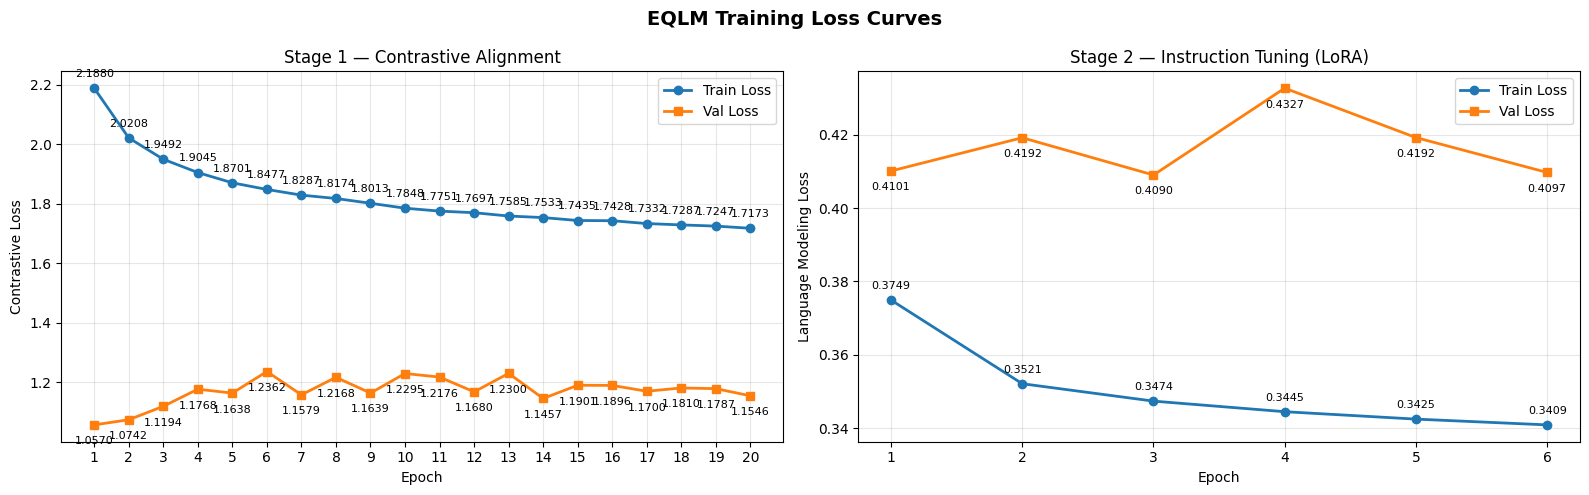

  ✓ Loss curves → /loggerhead/mikedeffino/Code/eqlm_lora_checkpoint_notebookcnnmoeALL/loss_curves_train_val.png
📥 Loading reports from /loggerhead/mikedeffino/Code/waveform_report_m1_d200.jsonl...
  ✓ Loaded 111,075 expert reports
📥 Opening HDF5: /loggerhead/mikedeffino/Code/chunk2.hdf5


  ✓ [EVAL] 11,108 waveform-report pairs

Ground truth:
 This record is a three-component local earthquake waveform from station B086 in network PB. The waveform contains 6000 samples across E, N, and Z channels at approximately 100.0 Hz. The event magnitude is 1.83, which falls in the very small range in this custom labeling scheme, and the source-to-station distance is 87.1 km, corresponding to a local-near local event. The P-wave arrival is annotated

Generated:
 in network ZQ. The waveform contains 6000 samples across E, N, and Z channels at approximately 100.0 Hz. The event magnitude is 2.40, which falls in the small range in this custom labeling scheme, and the source-to-station distance is 57.9 km, corresponding to a local-near local event. The P-wave arrival is annotated at sample 800. The S-wave arrival is annotated at sample 1692. The dominant peak amplitude appears on the E channel. Channel-wise absolute maxima are E=15555.000,


In [15]:
import matplotlib.pyplot as plt
save_dir = f"{CODE_DIR}/eqlm_lora_checkpoint_notebookcnnmoeALL"
os.makedirs(save_dir, exist_ok=True)

save_model(model, tokenizer, save_dir=save_dir)
save_loss_curves(
    stage1_train_loss, stage1_val_loss,
    train_loss2, val_loss2,
    save_dir=save_dir
)

test_dataset = PreFilteredSTEADDataset(cfg, tokenizer=tokenizer, stage=1, split="eval")
sample = test_dataset[0]
ground_truth = test_dataset.reports[test_dataset.valid_traces[0]]["report"]
generated = generate_report(model, cfg, tokenizer, sample["waveform"])

print("\nGround truth:\n", ground_truth[:400])
print("\nGenerated:\n", generated)

test_dataset.close()